## Import libraries


In [1]:
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hydrokit.utils import create_grids
from hydrokit.input.watershed import get_dem

## Load the region and create grids


(14, 4)


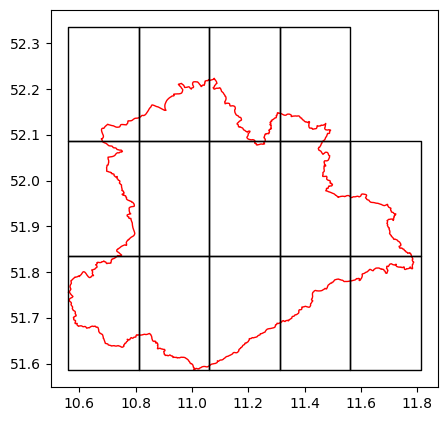

In [2]:
roi_path = "/beegfs/halder/GITHUB/PROJECT/hydrokit/data/raw/ROI/Bode_catchment.zip"
roi = gpd.read_file(roi_path)
roi_grids = create_grids(roi, resolution=0.25)

print(roi_grids.shape)

fig, ax = plt.subplots(figsize=(5, 5))
roi.plot(ax=ax, facecolor="none", edgecolor="red")
roi_grids.plot(ax=ax, facecolor="none")

plt.show()

## Download and process DEM data


In [3]:
# Extract bounding box from the first grid cell
bbox = list(roi_grids.iloc[0].geometry.bounds)
print(f"Bounding box: {bbox}")
print(f"Grid cell area: {roi_grids.iloc[0].geometry.area:.6f} sq. degrees")

# Download DEM data
out_path = "test_dem.tif"
ds = get_dem(bbox=bbox, out_path=out_path)

Bounding box: [10.56139298665, 51.585555915441, 10.81139298665, 51.835555915441]
Grid cell area: 0.062500 sq. degrees
Found 1 items
DEM saved to test_dem.tif
